# 01 â€” Exploration du dataset Credit Card Fraud Detection

Dataset Kaggle `mlg-ulb/creditcardfraud` : transactions par carte bancaire de titulaires europÃ©ens,
sur 2 jours de septembre 2013. Les variables `V1`-`V28` sont issues d'une transformation PCA
(anonymisation), `Time` est le nombre de secondes Ã©coulÃ©es depuis la premiÃ¨re transaction du
dataset, `Amount` est le montant de la transaction, et `Class` est la cible (0 = lÃ©gitime, 1 = fraude).

Le dÃ©fi central de ce dataset est le **dÃ©sÃ©quilibre extrÃªme des classes** (~0,17% de fraude).

## 1. Chargement et aperÃ§u

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/raw/creditcard.csv')
print('Shape:', df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## 2. Valeurs manquantes et doublons

In [3]:
missing = df.isna().sum()
print('Valeurs manquantes par colonne (total):', missing.sum())
print(missing[missing > 0])

n_dup = df.duplicated().sum()
print(f'Lignes dupliquÃ©es: {n_dup} ({n_dup / len(df):.3%})')

Valeurs manquantes par colonne (total):

 0
Series([], dtype: int64)


Lignes dupliquÃ©es: 1081 (0.380%)


## 3. Distribution de la variable cible `Class`

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


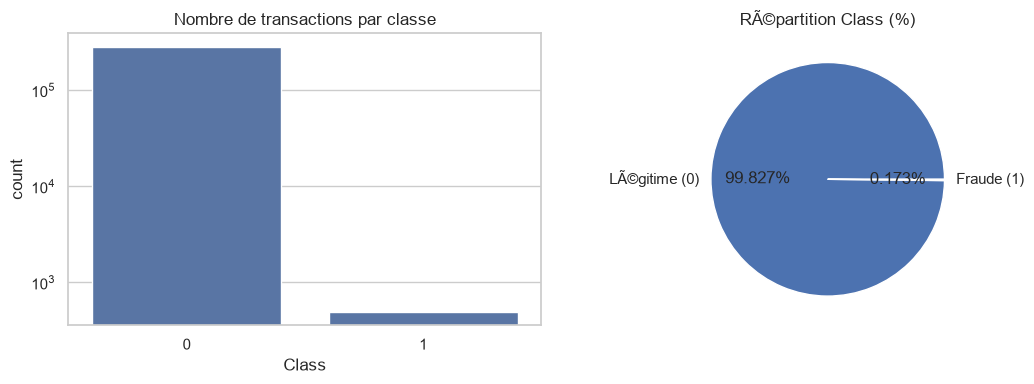

In [4]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct.round(4))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Class', data=df, ax=ax[0])
ax[0].set_title('Nombre de transactions par classe')
ax[0].set_yscale('log')

ax[1].pie(class_counts, labels=['LÃ©gitime (0)', 'Fraude (1)'], autopct='%1.3f%%',
          colors=['#4C72B0', '#C44E52'])
ax[1].set_title('RÃ©partition Class (%)')
plt.tight_layout()
plt.show()

**Constat :** la classe frauduleuse reprÃ©sente environ 0,17% des transactions
(~1 fraude pour ~577 transactions lÃ©gitimes). Toute stratÃ©gie de modÃ©lisation devra
gÃ©rer explicitement ce dÃ©sÃ©quilibre (pondÃ©ration de classe, mÃ©triques adaptÃ©es
comme l'AUC-PR plutÃ´t que l'accuracy, etc.).

## 4. Distribution de `Amount` (fraude vs non-fraude)

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


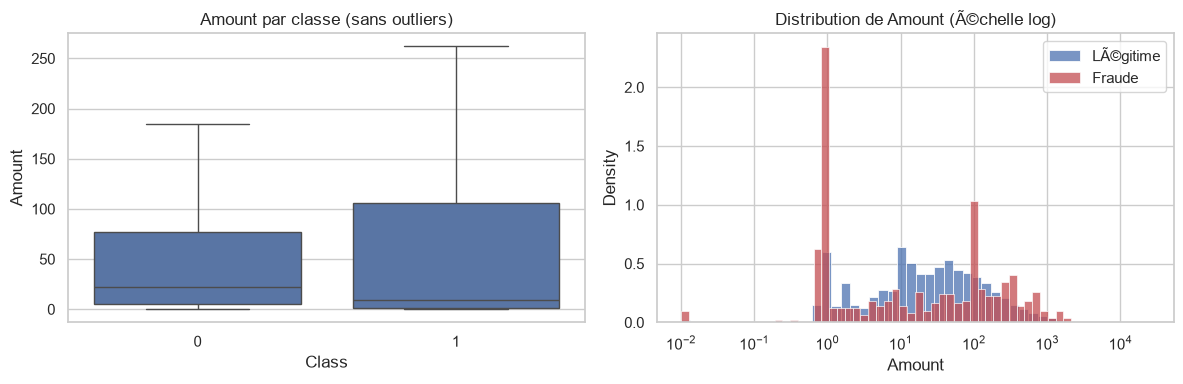

In [5]:
print(df.groupby('Class')['Amount'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Class', y='Amount', data=df, ax=ax[0], showfliers=False)
ax[0].set_title('Amount par classe (sans outliers)')

sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, color='#4C72B0', label='LÃ©gitime',
             stat='density', ax=ax[1], log_scale=(True, False))
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, color='#C44E52', label='Fraude',
             stat='density', ax=ax[1], log_scale=(True, False))
ax[1].set_title('Distribution de Amount (Ã©chelle log)')
ax[1].legend()
plt.tight_layout()
plt.show()

## 5. Distribution de `Time` (fraude vs non-fraude)

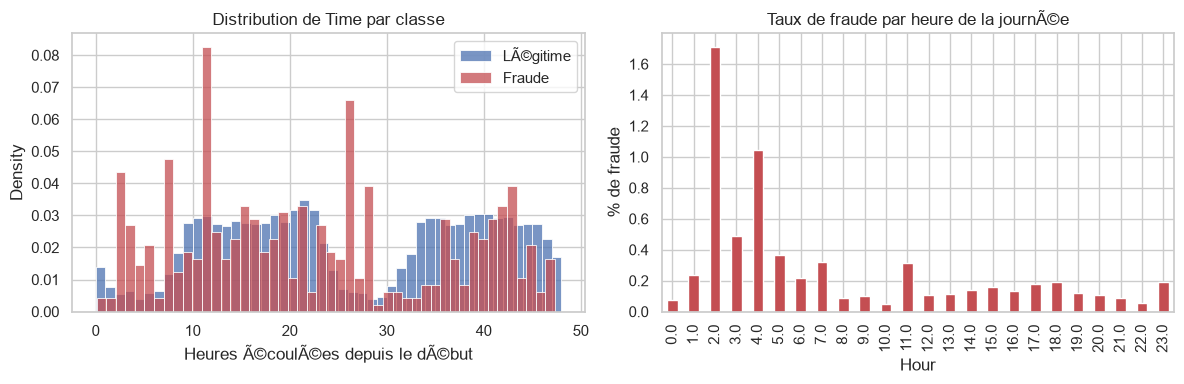

In [6]:
df['Hour'] = (df['Time'] // 3600) % 24

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[df['Class'] == 0]['Time'] / 3600, bins=48, color='#4C72B0',
             label='LÃ©gitime', stat='density', ax=ax[0])
sns.histplot(df[df['Class'] == 1]['Time'] / 3600, bins=48, color='#C44E52',
             label='Fraude', stat='density', ax=ax[0])
ax[0].set_xlabel('Heures Ã©coulÃ©es depuis le dÃ©but')
ax[0].set_title('Distribution de Time par classe')
ax[0].legend()

fraud_by_hour = df.groupby('Hour')['Class'].mean() * 100
fraud_by_hour.plot(kind='bar', ax=ax[1], color='#C44E52')
ax[1].set_ylabel('% de fraude')
ax[1].set_title('Taux de fraude par heure de la journÃ©e')
plt.tight_layout()
plt.show()

**Constat :** les transactions frauduleuses ne suivent pas le mÃªme rythme journalier
que les transactions lÃ©gitimes â€” on observe une part de fraude proportionnellement plus
Ã©levÃ©e durant les heures de faible trafic (nuit), ce qui justifie l'ajout d'une feature
cyclique dÃ©rivÃ©e de l'heure dans le pipeline de prÃ©paration.

## 6. CorrÃ©lation des variables V1-V28 avec `Class`

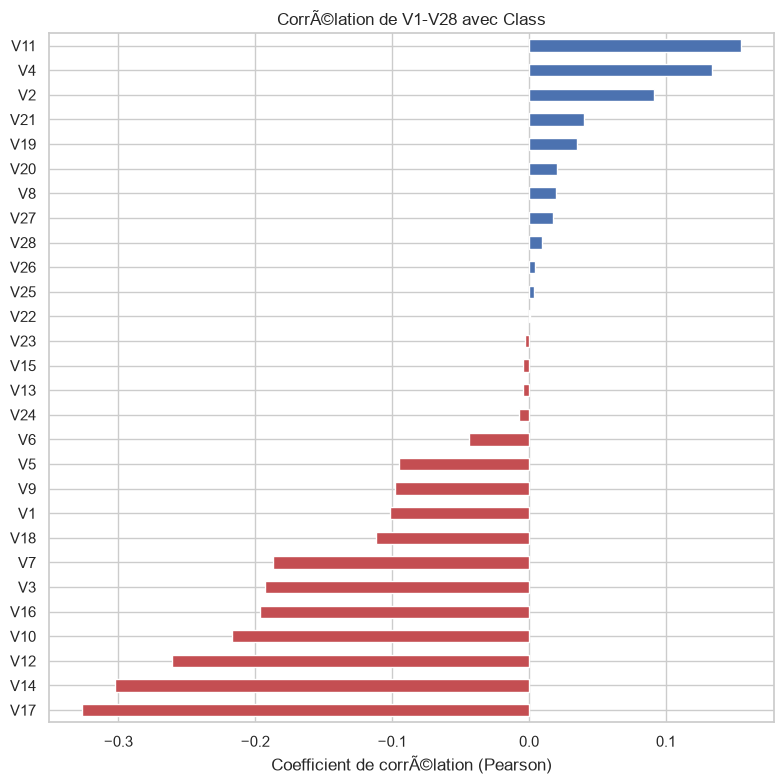

Top 5 corrÃ©lations positives:
V11    0.154876
V4     0.133447
V2     0.091289
V21    0.040413
V19    0.034783
Name: Class, dtype: float64

Top 5 corrÃ©lations nÃ©gatives:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
Name: Class, dtype: float64


In [7]:
v_cols = [c for c in df.columns if c.startswith('V')]
corr_with_class = df[v_cols + ['Class']].corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
corr_with_class.plot(kind='barh', ax=ax, color=corr_with_class.apply(lambda x: '#C44E52' if x < 0 else '#4C72B0'))
ax.set_title('CorrÃ©lation de V1-V28 avec Class')
ax.set_xlabel('Coefficient de corrÃ©lation (Pearson)')
plt.tight_layout()
plt.show()

print('Top 5 corrÃ©lations positives:')
print(corr_with_class.sort_values(ascending=False).head(5))
print('\nTop 5 corrÃ©lations nÃ©gatives:')
print(corr_with_class.sort_values().head(5))

## 7. SynthÃ¨se des enseignements clÃ©s

1. Le dataset ne contient **aucune valeur manquante** ; en revanche, ~1,08% de lignes
   sont des doublons exacts et devront Ãªtre supprimÃ©es en phase de nettoyage.
2. La classe cible est **extrÃªmement dÃ©sÃ©quilibrÃ©e** : seulement ~0,17% de fraude
   (492 transactions sur 284 807), ce qui interdit l'usage de l'accuracy seule comme
   mÃ©trique et impose une gestion explicite du dÃ©sÃ©quilibre (pondÃ©ration de classe,
   `scale_pos_weight`, AUC-PR, matrice de confusion).
3. Les montants (`Amount`) des transactions frauduleuses ont une distribution diffÃ©rente
   des transactions lÃ©gitimes, avec une mÃ©diane plus Ã©levÃ©e mais moins d'outliers extrÃªmes ;
   une transformation logarithmique (`log1p`) est pertinente pour rÃ©duire l'asymÃ©trie.
4. Les fraudes ne sont pas uniformÃ©ment rÃ©parties dans le temps : leur proportion varie
   selon l'heure de la journÃ©e, ce qui motive l'extraction d'une feature `Hour` cyclique
   (encodage sin/cos) plutÃ´t que d'utiliser `Time` brut.
5. Certaines variables PCA (`V17`, `V14`, `V12`, `V10`, `V16` cÃ´tÃ© nÃ©gatif ; `V11`, `V4`,
   `V2` cÃ´tÃ© positif) sont fortement corrÃ©lÃ©es Ã  `Class` et seront probablement les
   variables les plus prÃ©dictives des modÃ¨les â€” Ã  confirmer via l'analyse SHAP en Ã©tape 3.
6. `Amount` et `Time` sont les deux seules variables non anonymisÃ©es et Ã  des Ã©chelles
   trÃ¨s diffÃ©rentes des `V1`-`V28` (dÃ©jÃ  normalisÃ©es par la PCA) : elles nÃ©cessitent un
   scaling dÃ©diÃ© (RobustScaler, robuste aux outliers) avant modÃ©lisation.
7. Avec un tel dÃ©sÃ©quilibre, un split stratifiÃ© (`stratify=Class`) est indispensable pour
   garantir une proportion de fraude comparable entre les jeux d'entraÃ®nement et de test.